# Statistics Advance-3 Assignment
### Data Science Masters - PW Skills

## Q1. What is Estimation Statistics? Explain point estimate and interval estimate.

**Estimation Statistics:**
A branch of statistics where we use sample data to estimate unknown population parameters (like population mean, proportion, variance). Since we can't measure the entire population, we take a sample and estimate.

---

**Point Estimate:**
- A single value used to estimate the population parameter.
- Simple but gives no information about accuracy/uncertainty.
- Example: Sample mean (x̄) is a point estimate of population mean (μ).
  - If 50 students' avg score = 75, then point estimate of population mean = 75.

---

**Interval Estimate (Confidence Interval):**
- A range of values within which the population parameter likely falls.
- Comes with a confidence level (e.g., 95%) that tells how confident we are.
- Formula: x̄ ± (Z * σ/√n)
- Example: We estimate population mean score is between 72 and 78 with 95% confidence.
- More informative than point estimate — gives a sense of precision.

## Q2. Python function to estimate population mean using sample mean and standard deviation

In [1]:
import numpy as np
from scipy import stats

def estimate_population_mean(sample_mean, sample_std, n, confidence=0.95):
    """
    Estimate population mean using confidence interval.
    Parameters:
        sample_mean : mean of the sample
        sample_std  : standard deviation of the sample
        n           : sample size
        confidence  : confidence level (default 0.95)
    Returns:
        (point_estimate, lower_bound, upper_bound)
    """
    alpha = 1 - confidence
    # Use t-distribution (works for any n; for large n it approximates z)
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    margin_of_error = t_critical * (sample_std / np.sqrt(n))

    lower = sample_mean - margin_of_error
    upper = sample_mean + margin_of_error

    return sample_mean, lower, upper

# Example usage
mean, lower, upper = estimate_population_mean(
    sample_mean=75, sample_std=10, n=50, confidence=0.95
)
print(f"Point Estimate       : {mean}")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Point Estimate       : 75
95% Confidence Interval: (72.16, 77.84)


## Q3. What is Hypothesis Testing? Why is it used? Importance?

**Hypothesis Testing:**
A statistical procedure to make decisions or draw conclusions about a population based on sample data. We test whether a claim (hypothesis) about a population parameter is supported by evidence.

**Why is it used?**
- To validate assumptions or claims about populations using limited sample data.
- To decide whether observed differences are real or just due to random chance.
- Example: Does a new drug actually reduce blood pressure? Is the new teaching method better?

**Importance of Hypothesis Testing:**
1. **Scientific Decision Making**: Provides a formal framework to accept/reject claims with measurable confidence.
2. **Reduces Guesswork**: Replaces intuition with data-driven conclusions.
3. **Controls Error**: Quantifies the risk of making wrong decisions (Type I & Type II errors).
4. **Widely applicable**: Used in medicine, business, engineering, ML model evaluation, A/B testing.
5. **Reproducible**: Other researchers can verify results using the same methodology.

## Q4. Hypothesis: Average weight of male vs female college students

**Research Question:** Is the average weight of male college students greater than the average weight of female college students?

**Null Hypothesis (H₀):**
The average weight of male college students is equal to (or less than) the average weight of female college students.
H₀: μ_male ≤ μ_female

**Alternative Hypothesis (H₁):**
The average weight of male college students is greater than the average weight of female college students.
H₁: μ_male > μ_female

**Test Type:** One-tailed (right-tailed) two-sample t-test

**Significance Level:** α = 0.05

We reject H₀ if p-value < 0.05, meaning there is sufficient evidence that males weigh more on average.

## Q5. Python script for hypothesis test on difference between two population means

In [2]:
import numpy as np
from scipy import stats

def two_sample_hypothesis_test(sample1, sample2, alpha=0.05, alternative='two-sided'):
    """
    Conduct a two-sample t-test for independent samples.
    Parameters:
        sample1     : array-like, first sample
        sample2     : array-like, second sample
        alpha       : significance level (default 0.05)
        alternative : 'two-sided', 'greater', or 'less'
    """
    n1, n2 = len(sample1), len(sample2)
    mean1, mean2 = np.mean(sample1), np.mean(sample2)
    std1, std2   = np.std(sample1, ddof=1), np.std(sample2, ddof=1)

    t_stat, p_value = stats.ttest_ind(sample1, sample2, alternative=alternative)

    print("======= Two-Sample t-Test =======")
    print(f"Sample 1 → n={n1}, mean={mean1:.4f}, std={std1:.4f}")
    print(f"Sample 2 → n={n2}, mean={mean2:.4f}, std={std2:.4f}")
    print(f"t-statistic : {t_stat:.4f}")
    print(f"p-value     : {p_value:.4f}")
    print(f"Alpha       : {alpha}")

    if p_value < alpha:
        print("Result: REJECT H₀ — Significant difference exists between the two population means.")
    else:
        print("Result: FAIL TO REJECT H₀ — No significant difference between the two population means.")

# Generate random samples (simulating male and female weights)
np.random.seed(42)
male_weights   = np.random.normal(loc=72, scale=10, size=50)  # male sample
female_weights = np.random.normal(loc=60, scale=8,  size=50)  # female sample

two_sample_hypothesis_test(male_weights, female_weights, alpha=0.05, alternative='greater')

======= Two-Sample t-Test =======
Sample 1 → n=50, mean=69.7453, std=9.3367
Sample 2 → n=50, mean=60.1422, std=6.9946
t-statistic : 5.8206
p-value     : 0.0000
Alpha       : 0.05
Result: REJECT H₀ — Significant difference exists between the two population means.


## Q6. What is Null and Alternative Hypothesis? Give examples.

**Null Hypothesis (H₀):**
- The default assumption — states that there is NO effect, NO difference, or NO relationship.
- We assume H₀ is true until evidence proves otherwise.
- Always contains equality (=, ≤, ≥).

**Alternative Hypothesis (H₁ or Hₐ):**
- The claim we want to test — states that there IS an effect, difference, or relationship.
- We accept H₁ only if there is strong evidence against H₀.
- Contains inequality (≠, >, <).

---

**Examples:**

1. Drug effectiveness:
   - H₀: The new drug has no effect on blood pressure. (μ = 0 reduction)
   - H₁: The new drug reduces blood pressure. (μ > 0 reduction)

2. Coin fairness:
   - H₀: The coin is fair. (p = 0.5)
   - H₁: The coin is biased. (p ≠ 0.5)

3. Student performance:
   - H₀: Online and offline teaching have equal exam results. (μ₁ = μ₂)
   - H₁: Online teaching gives different results than offline. (μ₁ ≠ μ₂)

4. Manufacturing:
   - H₀: Average product weight = 500g. (μ = 500)
   - H₁: Average product weight < 500g. (μ < 500)

## Q7. Steps involved in Hypothesis Testing

**Steps in Hypothesis Testing:**

1. **State the Hypotheses**
   - Define H₀ (null hypothesis) and H₁ (alternative hypothesis).

2. **Set the Significance Level (α)**
   - Commonly α = 0.05 (5%) or 0.01 (1%).
   - This is the threshold for rejecting H₀.

3. **Choose the Appropriate Test**
   - Based on data type and conditions: z-test, t-test, chi-square test, ANOVA, etc.

4. **Collect Data and Calculate Test Statistic**
   - Compute the test statistic (z, t, F, χ²) from the sample data.

5. **Find the p-value (or Critical Value)**
   - p-value = probability of observing the result if H₀ were true.

6. **Make a Decision**
   - If p-value < α → Reject H₀ (evidence supports H₁)
   - If p-value ≥ α → Fail to reject H₀ (insufficient evidence against H₀)

7. **State the Conclusion**
   - Interpret the result in context of the original problem.

## Q8. Define p-value and explain its significance in hypothesis testing

**p-value:**
The probability of obtaining a test result at least as extreme as the observed result, assuming the null hypothesis (H₀) is true.

In simple terms: p-value tells us how likely our sample result is if H₀ were actually true.

**Significance in Hypothesis Testing:**

| p-value | Interpretation |
|---|---|
| p < 0.01 | Very strong evidence against H₀ → Reject H₀ |
| p < 0.05 | Strong evidence against H₀ → Reject H₀ |
| p < 0.10 | Weak evidence against H₀ |
| p ≥ 0.05 | Insufficient evidence → Fail to reject H₀ |

**Key Points:**
- Small p-value → data is unlikely under H₀ → reject H₀.
- Large p-value → data is consistent with H₀ → don't reject H₀.
- p-value does NOT tell the probability that H₀ is true — it's the probability of the data given H₀ is true.
- Example: p-value = 0.03 means there's only a 3% chance of getting this result if H₀ were true — strong evidence to reject H₀ at α=0.05.

## Q9. Student's t-distribution plot (degrees of freedom = 10)

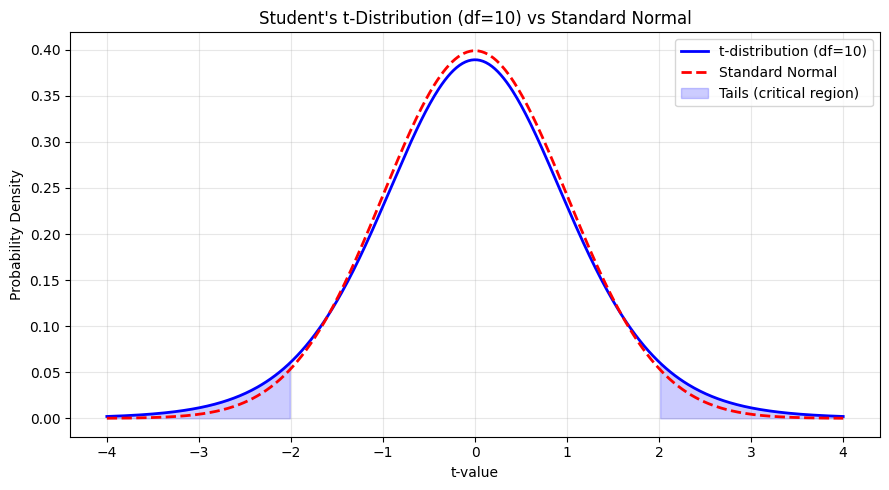

Note: t-distribution has heavier tails than normal — accounts for extra uncertainty with small samples.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

x = np.linspace(-4, 4, 500)

plt.figure(figsize=(9, 5))

# t-distribution with df=10
plt.plot(x, t.pdf(x, df=10), 'b-', linewidth=2, label="t-distribution (df=10)")

# Standard Normal for comparison
plt.plot(x, norm.pdf(x, 0, 1), 'r--', linewidth=2, label="Standard Normal")

# Shade critical regions
plt.fill_between(x, t.pdf(x, df=10), where=(x < -2), color='blue', alpha=0.2, label='Tails (critical region)')
plt.fill_between(x, t.pdf(x, df=10), where=(x > 2),  color='blue', alpha=0.2)

plt.title("Student's t-Distribution (df=10) vs Standard Normal")
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: t-distribution has heavier tails than normal — accounts for extra uncertainty with small samples.")

## Q10. Two-sample t-test for independent samples

In [4]:
import numpy as np
from scipy import stats

np.random.seed(0)

# Two random samples of equal size
sample_A = np.random.normal(loc=50, scale=10, size=30)
sample_B = np.random.normal(loc=52, scale=10, size=30)

# H0: μ_A = μ_B (population means are equal)
t_stat, p_value = stats.ttest_ind(sample_A, sample_B)

alpha = 0.05
print("======= Two-Sample t-Test (Independent) =======")
print(f"H₀: μ_A = μ_B")
print(f"H₁: μ_A ≠ μ_B")
print(f"\nSample A → mean={sample_A.mean():.4f}, std={sample_A.std(ddof=1):.4f}, n={len(sample_A)}")
print(f"Sample B → mean={sample_B.mean():.4f}, std={sample_B.std(ddof=1):.4f}, n={len(sample_B)}")
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — The two population means are significantly different.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant difference between population means.")

======= Two-Sample t-Test (Independent) =======
H₀: μ_A = μ_B
H₁: μ_A ≠ μ_B

Sample A → mean=54.4286, std=11.0033, n=30
Sample B → mean=49.1048, std=9.1424, n=30

t-statistic : 2.0383
p-value     : 0.0461
Alpha       : 0.05

Result: REJECT H₀ — The two population means are significantly different.


## Q11. What is Student's t-distribution? When to use it?

**Student's t-Distribution:**
- A probability distribution similar to the normal distribution but with **heavier tails**.
- Developed by William Gosset (published under pseudonym 'Student') in 1908.
- Defined by **degrees of freedom (df = n - 1)**.
- As df → ∞, t-distribution → Standard Normal distribution.

**Why heavier tails?**
Small samples have more uncertainty, so there's a higher chance of extreme values — t-distribution accounts for this.

---

**When to use t-Distribution:**
1. **Small sample size** (n < 30) — when normal distribution assumptions don't hold.
2. **Population standard deviation (σ) is unknown** — using sample std (s) instead.
3. **Data is approximately normally distributed** (or sample is reasonably large).

**Use Cases:**
- One-sample t-test: Is sample mean equal to a claimed value?
- Two-sample t-test: Are two group means equal?
- Paired t-test: Before/after comparison for same subjects.
- Constructing confidence intervals when σ is unknown.

## Q12. What is t-statistic? State the formula.

**t-statistic:**
A value that measures how many standard errors the sample mean is away from the hypothesized population mean. It quantifies the difference relative to the variability in the data.

---

**Formula for One-Sample t-test:**

t = (x̄ - μ₀) / (s / √n)

Where:
- x̄  = sample mean
- μ₀ = hypothesized population mean (from H₀)
- s  = sample standard deviation
- n  = sample size
- s/√n = standard error of the mean

---

**Formula for Two-Sample t-test (equal variance assumed):**

t = (x̄₁ - x̄₂) / (sp × √(1/n₁ + 1/n₂))

Where sp = pooled standard deviation = √[((n₁-1)s₁² + (n₂-1)s₂²) / (n₁+n₂-2)]

---

**Interpretation:**
- Large |t| → sample mean is far from H₀ → more likely to reject H₀.
- Small |t| → sample mean is close to H₀ → less likely to reject H₀.

## Q13. 95% Confidence Interval for coffee shop daily revenue

In [5]:
import numpy as np
from scipy import stats

# Given data
n           = 50
sample_mean = 500
sample_std  = 50
confidence  = 0.95
alpha       = 1 - confidence

# Using z-distribution (n=50, large enough)
z_critical = stats.norm.ppf(1 - alpha/2)
margin_of_error = z_critical * (sample_std / np.sqrt(n))

lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== Coffee Shop Revenue - 95% Confidence Interval =====")
print(f"Sample Mean        : ${sample_mean}")
print(f"Sample Std Dev     : ${sample_std}")
print(f"Sample Size (n)    : {n}")
print(f"Z-critical (95%)   : {z_critical:.4f}")
print(f"Margin of Error    : ${margin_of_error:.2f}")
print(f"\n95% CI: (${lower:.2f}, ${upper:.2f})")
print(f"\nInterpretation: We are 95% confident that the true average daily revenue")
print(f"lies between ${lower:.2f} and ${upper:.2f}.")

===== Coffee Shop Revenue - 95% Confidence Interval =====
Sample Mean        : $500
Sample Std Dev     : $50
Sample Size (n)    : 50
Z-critical (95%)   : 1.9600
Margin of Error    : $13.86

95% CI: ($486.14, $513.86)

Interpretation: We are 95% confident that the true average daily revenue
lies between $486.14 and $513.86.


## Q14. Hypothesis test — Drug effect on blood pressure (α = 0.05)

In [6]:
import numpy as np
from scipy import stats

# Given data
n           = 100
sample_mean = 8      # observed decrease
sample_std  = 3
mu_0        = 10     # hypothesized decrease (H0)
alpha       = 0.05

# H0: μ = 10 (drug decreases BP by 10 mmHg)
# H1: μ < 10 (drug decreases less than expected) — one-tailed (left)

t_stat = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
p_value = stats.t.cdf(t_stat, df=n-1)  # left-tailed

print("===== Blood Pressure Drug Hypothesis Test =====")
print(f"H₀: μ = 10 mmHg decrease")
print(f"H₁: μ < 10 mmHg decrease (one-tailed left)")
print(f"\nSample mean decrease : {sample_mean} mmHg")
print(f"Sample std           : {sample_std} mmHg")
print(f"n                    : {n}")
print(f"t-statistic          : {t_stat:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Alpha                : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — The drug does NOT decrease BP by 10 mmHg; actual decrease is significantly less.")
else:
    print("\nResult: FAIL TO REJECT H₀ — Insufficient evidence that the drug's effect differs from 10 mmHg.")

===== Blood Pressure Drug Hypothesis Test =====
H₀: μ = 10 mmHg decrease
H₁: μ < 10 mmHg decrease (one-tailed left)

Sample mean decrease : 8 mmHg
Sample std           : 3 mmHg
n                    : 100
t-statistic          : -6.6667
p-value              : 0.0000
Alpha                : 0.05

Result: REJECT H₀ — The drug does NOT decrease BP by 10 mmHg; actual decrease is significantly less.


## Q15. Hypothesis test — Product weight < 5 pounds (α = 0.01)

In [7]:
import numpy as np
from scipy import stats

# Given data
n           = 25
sample_mean = 4.8
pop_std     = 0.5    # population std is KNOWN → use z-test
mu_0        = 5.0
alpha       = 0.01

# H0: μ = 5 pounds
# H1: μ < 5 pounds (one-tailed left)

z_stat  = (sample_mean - mu_0) / (pop_std / np.sqrt(n))
p_value = stats.norm.cdf(z_stat)  # left-tailed

print("===== Electronics Product Weight Hypothesis Test =====")
print(f"H₀: μ = 5 pounds")
print(f"H₁: μ < 5 pounds (one-tailed left, z-test)")
print(f"\nSample mean : {sample_mean} lbs")
print(f"Pop std     : {pop_std} lbs")
print(f"n           : {n}")
print(f"z-statistic : {z_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — True mean weight is significantly less than 5 pounds.")
else:
    print("\nResult: FAIL TO REJECT H₀ — Not enough evidence that mean weight is less than 5 pounds.")

===== Electronics Product Weight Hypothesis Test =====
H₀: μ = 5 pounds
H₁: μ < 5 pounds (one-tailed left, z-test)

Sample mean : 4.8 lbs
Pop std     : 0.5 lbs
n           : 25
z-statistic : -2.0000
p-value     : 0.0228
Alpha       : 0.01

Result: FAIL TO REJECT H₀ — Not enough evidence that mean weight is less than 5 pounds.


## Q16. Two-sample t-test — Two groups of students (α = 0.01)

In [8]:
import numpy as np
from scipy import stats

# Given data
n1, mean1, std1 = 30, 80, 10
n2, mean2, std2 = 40, 75, 8
alpha = 0.01

# H0: μ1 = μ2
# H1: μ1 ≠ μ2 (two-tailed)

# Pooled standard error
se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
t_stat = (mean1 - mean2) / se

# Degrees of freedom (Welch's approximation)
df = ((std1**2/n1 + std2**2/n2)**2) / \
     ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))

p_value = 2 * stats.t.sf(abs(t_stat), df=df)  # two-tailed

print("===== Two-Group Student Score Hypothesis Test =====")
print(f"H₀: μ₁ = μ₂ (population means are equal)")
print(f"H₁: μ₁ ≠ μ₂ (two-tailed)")
print(f"\nGroup 1 → mean={mean1}, std={std1}, n={n1}")
print(f"Group 2 → mean={mean2}, std={std2}, n={n2}")
print(f"t-statistic : {t_stat:.4f}")
print(f"Degrees of freedom: {df:.2f}")
print(f"p-value     : {p_value:.4f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nResult: REJECT H₀ — Significant difference exists between the two groups.")
else:
    print("\nResult: FAIL TO REJECT H₀ — No significant difference between the two groups.")

===== Two-Group Student Score Hypothesis Test =====
H₀: μ₁ = μ₂ (population means are equal)
H₁: μ₁ ≠ μ₂ (two-tailed)

Group 1 → mean=80, std=10, n=30
Group 2 → mean=75, std=8, n=40
t-statistic : 2.2511
Degrees of freedom: 54.23
p-value     : 0.0285
Alpha       : 0.01

Result: FAIL TO REJECT H₀ — No significant difference between the two groups.


## Q17. 99% Confidence Interval — Average ads watched by TV viewers

In [9]:
import numpy as np
from scipy import stats

# Given data
n           = 50
sample_mean = 4
sample_std  = 1.5
confidence  = 0.99
alpha       = 1 - confidence

# Using z-distribution (n=50, large enough)
z_critical      = stats.norm.ppf(1 - alpha/2)
margin_of_error = z_critical * (sample_std / np.sqrt(n))

lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("===== TV Ads Watched - 99% Confidence Interval =====")
print(f"Sample Mean        : {sample_mean} ads")
print(f"Sample Std Dev     : {sample_std}")
print(f"Sample Size (n)    : {n}")
print(f"Z-critical (99%)   : {z_critical:.4f}")
print(f"Margin of Error    : {margin_of_error:.4f}")
print(f"\n99% CI: ({lower:.4f}, {upper:.4f})")
print(f"\nInterpretation: We are 99% confident that the true average number of ads")
print(f"watched by viewers lies between {lower:.2f} and {upper:.2f}.")

===== TV Ads Watched - 99% Confidence Interval =====
Sample Mean        : 4 ads
Sample Std Dev     : 1.5
Sample Size (n)    : 50
Z-critical (99%)   : 2.5758
Margin of Error    : 0.5464

99% CI: (3.4536, 4.5464)

Interpretation: We are 99% confident that the true average number of ads
watched by viewers lies between 3.45 and 4.55.
